# SmartStay AI: Keşifsel Veri Analizi (EDA), Veri Temizleme ve Aykırı Değer Analizi

Bu doküman, **SmartStay AI** projesinin veri bilimi modülü kapsamındaki Keşifsel Veri Analizi (EDA), Veri Ön İşleme (Data Preprocessing) ve Aykırı Değer (Outlier) Analizi süreçlerini içermektedir. Inside Airbnb İstanbul veri seti üzerinde yapısal, istatistiksel ve dağılım analizleri gerçekleştirilmiş; eksik ve aykırı değerler temizlenerek regresyon ve öneri motoru modelleri için güvenilir bir veri seti (`data/processed/cleaned_listings.csv`) oluşturulmuştur.

---

### Metodolojik Süreç
1. **Keşifsel Veri Analizi (Bölüm I):**
   * Veri seti şeması, değişken tipleri ve boyut analizi (`df.info()`, `df.describe()`).
   * Eksik veri ve seyreklik (sparsity) analizi (>%50 eşik değeri tespiti).
   * Değişkenlerin sayısal ve kategorik olarak ayrıştırılması.
   * Hedef değişken (`price`) dağılımının incelenmesi.
   * Oda tipleri (`room_type`) ve konumsal dağılımların (`neighbourhood_cleansed`) incelenmesi.

2. **Veri Temizleme ve İmpütasyon (Bölüm II):**
   * %50'den fazla eksik veri içeren 14 sütunun ayıklanması.
   * Fiyat kolonunun sayısal tipe dönüştürülmesi ve etiketi eksik gözlemlerin filtrelenmesi.
   * Kalan değişkenlerin alan uzmanlığına uygun yöntemlerle (medyan, 0.0 veya 'Unknown') doldurulması.

3. **Aykırı Değer (Outlier) Analizi ve Filtreleme (Bölüm III):**
   * `price` değişkeni için IQR (Interquartile Range) sınırlarının hesaplanması ($Q_1, Q_3, IQR, \text{Alt/Üst Sınırlar}$).
   * Uç değerlerin tespit edilmesi, oranlanması ve filtrelenmesi.
   * Filtreleme öncesi ve sonrası boxplot / yoğunluk dağılımlarının karşılaştırılması.
   * Nihai işlenmiş veri setinin `data/processed/cleaned_listings.csv` olarak güncellenmesi.


## 1. Ortam Yapılandırması ve Bağımlılıklar

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 2. Ham Veri Setinin Belleğe Yüklenmesi

In [2]:
raw_data_path = os.path.join('..', 'data', 'raw', 'listings.csv')
df_raw = pd.read_csv(raw_data_path)

print(f"Gözlem (Satır) Sayısı: {df_raw.shape[0]:,}")
print(f"Değişken (Sütun) Sayısı: {df_raw.shape[1]}")
df_raw.head(3)

Gözlem (Satır) Sayısı: 26,631
Değişken (Sütun) Sayısı: 90


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,25436,https://www.airbnb.com/rooms/25436,20260630053558,2026-07-03,previous scrape,In the forest Sea view Two minutes to the city.,Our house is in Bebek Koru. If you want villag...,NaN,https://a0.muscache.com/pictures/b64c3ef0-2256...,105823,https://www.airbnb.com/users/show/105823,1462509707466640732,https://www.airbnb.com/users/profile/146250970...,Yesim,NaN,16,2,15,6,"İstanbul, Turkey","Merhabalar . Kuş sesi , akan su sesi ile uyan...",NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/067a8...,NaN,1,NaN,NaN,t,t,NaN,Besiktas,NaN,41.08,29.04,Entire rental unit,Entire home/apt,3,NaN,1 bath,2.00,NaN,"[""Sound system"", ""Barbecue utensils"", ""Free pa...",NaN,NaN,NaN,NaN,NaN,NaN,100.00,160.00,100.00,100.00,160.00,160.00,100.00,160.00,NaN,t,0,0,0,0,2026-07-03,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
1,34177,https://www.airbnb.com/rooms/34177,20260630053558,2026-07-03,previous scrape,PETIT HOUSE,My petit house is located in the bosphorous an...,NaN,https://a0.muscache.com/pictures/47356451/c288...,147330,https://www.airbnb.com/users/show/147330,1462510899379737925,https://www.airbnb.com/users/profile/146251089...,Ercan,NaN,16,0,15,6,"Istanbul, Turkey",grounded and well-traveled interior architect,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/147330/profil...,NaN,2,NaN,NaN,t,t,NaN,Besiktas,NaN,41.07,29.04,Entire home,Entire home/apt,3,NaN,1 bath,1.00,NaN,"[""Microwave"", ""Fire extinguisher"", ""Refrigerat...","$1,356.82",2026-07-04,2026-10-12,135681.69,1356.82,"{""quote"": {""taxes"": null, ""currency"": null, ""d...",100.00,365.00,100.00,100.00,365.00,365.00,100.00,365.00,NaN,t,29,59,89,364,2026-07-03,16,0,0,181,0,0,0.00,2015-12-29,2024-01-03,4.69,4.69,4.88,4.88,4.81,4.69,4.81,NaN,NaN,2,2,0,0,0.13
2,42835,https://www.airbnb.com/rooms/42835,20260630053558,2026-07-03,previous scrape,Cozy apartment in the heart of Istanbul,Welcome to our cozy 2-bedroom apartment locate...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,187026,https://www.airbnb.com/users/show/187026,1462512109122697564,https://www.airbnb.com/users/profile/146251210...,Attila,NaN,15,11,15,6,"Istanbul, Turkey",I am from Istanbul/ Turkey. I will do my best ...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/187026/profil...,NaN,3,NaN,NaN,t,t,NaN,Sisli,NaN,41.04,28.98,Entire rent

## 3. Veri Şeması ve Tip Analizi

In [3]:
df_raw.info(verbose=False, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 26631 entries, 0 to 26630
Columns: 90 entries, id to reviews_per_month
dtypes: float64(37), int64(24), str(29)
memory usage: 18.3 MB


In [4]:
dtype_distribution = df_raw.dtypes.value_counts().reset_index()
dtype_distribution.columns = ['Veri Tipi', 'Kolon Sayısı']
dtype_distribution

,Veri Tipi,Kolon Sayısı
0,float64,37
1,str,29
2,int64,24


In [5]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,26631.00,954563225373855616.00,536161971076064384.00,25436.00,707238894309436800.00,1000515312687092864.00,1406669945719909120.00,1718639795647937792.00
scrape_id,26631.00,20260630053558.00,0.00,20260630053558.00,20260630053558.00,20260630053558.00,20260630053558.00,20260630053558.00
neighborhood_overview,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,26631.00,22828919735197600.00,195028741099205472.00,85923.00,184465942.50,421844037.00,520046156.00,1717166899612739840.00
host_profile_id,26631.00,1476805616109044224.00,39046339178448928.00,1462509243176855552.00,1463541145760058112.00,1469443363461647360.00,1470305763658696192.00,1717940683362909184.00
host_since,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,26631.00,5.23,3.63,0.00,3.00,4.00,8.00,16.00
hosts_time_as_user_months,26631.00,5.88,3.57,0.00,3.00,6.00,9.00,11.00
hosts_time_as_host_years,26631.00,4.17,3.25,0.00,2.00,3.00,6.00,15.00
hosts_time_as_host_months,26631.00,5.67,3.47,0.00,3.00,6.00,9.00,11.00


## 4. Değişkenlerin Sayısal ve Kategorik Olarak Sınıflandırılması

In [6]:
numerical_columns = df_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df_raw.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()

print(f"Sayısal Değişken Sayısı: {len(numerical_columns)}")
print(f"Kategorik / Metin Değişken Sayısı: {len(categorical_columns)}")

Sayısal Değişken Sayısı: 61
Kategorik / Metin Değişken Sayısı: 29


## 5. Eksik Değer (Missing Value) ve Seyreklik Analizi

In [7]:
missing_counts = df_raw.isnull().sum()
missing_ratios = (100 * missing_counts / len(df_raw))

missing_summary = pd.DataFrame({
    'Degisken_Adi': df_raw.columns,
    'Veri_Tipi': df_raw.dtypes.astype(str),
    'Eksik_Sayisi': missing_counts,
    'Eksik_Orani_Pct': missing_ratios
}).reset_index(drop=True)

missing_summary_filtered = missing_summary[missing_summary['Eksik_Sayisi'] > 0].sort_values(
    by='Eksik_Orani_Pct', ascending=False
).reset_index(drop=True)

missing_summary_filtered.head(25)

,Degisken_Adi,Veri_Tipi,Eksik_Sayisi,Eksik_Orani_Pct
0,neighborhood_overview,float64,26631,100.00
1,host_since,float64,26631,100.00
2,host_neighbourhood,float64,26631,100.00
3,host_thumbnail_url,float64,26631,100.00
4,host_acceptance_rate,float64,26631,100.00
5,host_response_rate,float64,26631,100.00
6,host_response_time,float64,26631,100.00
7,host_verifications,float64,26631,100.00
8,host_total_listings_count,float64,26631,100.00
9,neighbourhood,float64,26631,100.00


### 5.1. Yüksek Seyreklik Gösteren Değişkenlerin Tespiti (>%50 Eşik Değeri)

In [8]:
high_sparsity_columns = missing_summary[missing_summary['Eksik_Orani_Pct'] > 50].sort_values(
    by='Eksik_Orani_Pct', ascending=False
).reset_index(drop=True)

print(f"Yüksek Seyreklik (>%50) Gösteren Kolon Sayısı: {len(high_sparsity_columns)}")
high_sparsity_columns

Yüksek Seyreklik (>%50) Gösteren Kolon Sayısı: 14


,Degisken_Adi,Veri_Tipi,Eksik_Sayisi,Eksik_Orani_Pct
0,neighborhood_overview,float64,26631,100.00
1,host_since,float64,26631,100.00
2,host_response_time,float64,26631,100.00
3,host_response_rate,float64,26631,100.00
4,host_acceptance_rate,float64,26631,100.00
5,host_thumbnail_url,float64,26631,100.00
6,neighbourhood,float64,26631,100.00
7,host_neighbourhood,float64,26631,100.00
8,host_total_listings_count,float64,26631,100.00
9,host_verifications,float64,26631,100.00


## 6. Hedef Değişken (`price`) Dağılımı ve İstatistiksel Analiz

In [9]:
df_eda_price = df_raw['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_eda_price = pd.to_numeric(df_eda_price, errors='coerce')

price_stats = df_eda_price.describe()
price_quantiles = df_eda_price.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999])

print("Fiyat Değişkeni Tanımlayıcı İstatistikleri:")
print(price_stats)
print("\nFiyat Yüzdelik Dilimleri (Quantiles):")
print(price_quantiles)

Fiyat Değişkeni Tanımlayıcı İstatistikleri:
count     23943.00
mean       4347.11
std       14817.62
min          12.40
25%        1008.83
50%        2853.00
75%        5190.03
max     1706000.45
Name: price, dtype: float64

Fiyat Yüzdelik Dilimleri (Quantiles):
0.01     135.41
0.05     255.33
0.10     400.58
0.25    1008.83
0.50    2853.00
0.75    5190.03
0.90    8527.68
0.95   11831.20
0.99   26345.00
1.00   78315.75
Name: price, dtype: float64


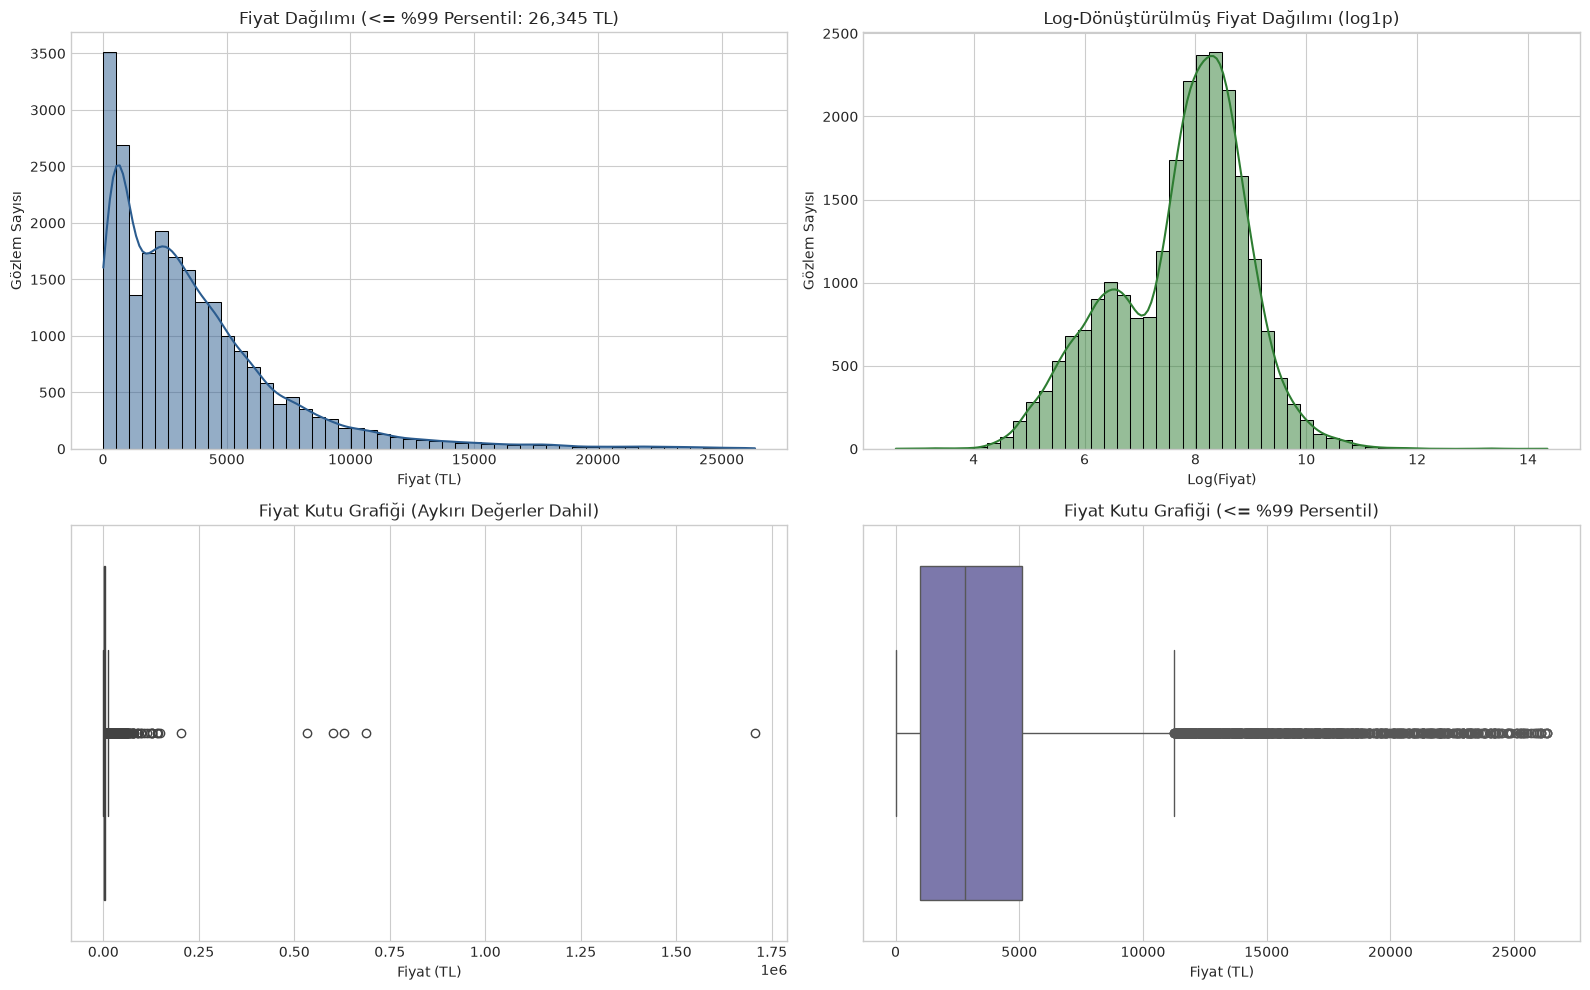

In [10]:
valid_prices = df_eda_price.dropna()
p99 = valid_prices.quantile(0.99)
log_prices = np.log1p(valid_prices[valid_prices > 0])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Ham Fiyat Dağılımı (99. persentile kadar)
sns.histplot(valid_prices[valid_prices <= p99], bins=50, kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title(f'Fiyat Dağılımı (<= %99 Persentil: {p99:,.0f} TL)', fontsize=12)
axes[0, 0].set_xlabel('Fiyat (TL)', fontsize=10)
axes[0, 0].set_ylabel('Gözlem Sayısı', fontsize=10)

# 2. Log-Dönüştürülmüş Fiyat Dağılımı
sns.histplot(log_prices, bins=50, kde=True, ax=axes[0, 1], color='#2e7d32')
axes[0, 1].set_title('Log-Dönüştürülmüş Fiyat Dağılımı (log1p)', fontsize=12)
axes[0, 1].set_xlabel('Log(Fiyat)', fontsize=10)
axes[0, 1].set_ylabel('Gözlem Sayısı', fontsize=10)

# 3. Kutu Grafiği (Genel Dağılım)
sns.boxplot(x=valid_prices, ax=axes[1, 0], color='#d95f02')
axes[1, 0].set_title('Fiyat Kutu Grafiği (Aykırı Değerler Dahil)', fontsize=12)
axes[1, 0].set_xlabel('Fiyat (TL)', fontsize=10)

# 4. Kutu Grafiği (<= %99 Persentil)
sns.boxplot(x=valid_prices[valid_prices <= p99], ax=axes[1, 1], color='#7570b3')
axes[1, 1].set_title(f'Fiyat Kutu Grafiği (<= %99 Persentil)', fontsize=12)
axes[1, 1].set_xlabel('Fiyat (TL)', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Kategorik Değişkenlerin ve Mekânsal Dağılımın İncelenmesi

Oda Tipi Dağılımı:
                 Gozlem_Sayisi  Oran_Pct
room_type                               
Entire home/apt          17939     67.36
Private room              8246     30.96
Hotel room                 309      1.16
Shared room                137      0.51


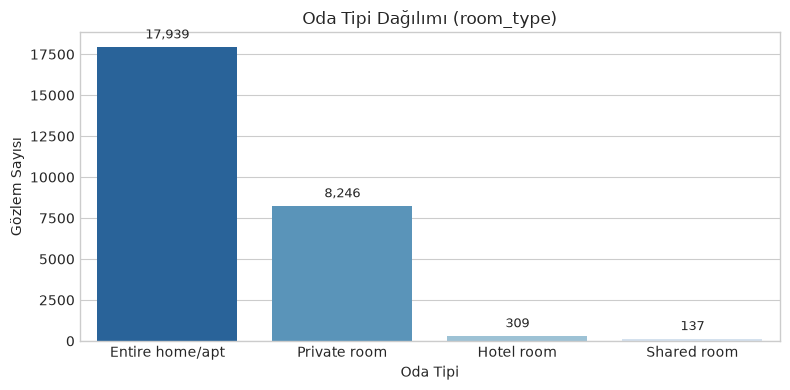

In [11]:
room_distribution = pd.DataFrame({
    'Gozlem_Sayisi': df_raw['room_type'].value_counts(dropna=False),
    'Oran_Pct': df_raw['room_type'].value_counts(normalize=True, dropna=False) * 100
})

print("Oda Tipi Dağılımı:")
print(room_distribution)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=room_distribution.index, y='Gozlem_Sayisi', data=room_distribution, palette='Blues_r')
plt.title('Oda Tipi Dağılımı (room_type)', fontsize=12)
plt.xlabel('Oda Tipi', fontsize=10)
plt.ylabel('Gözlem Sayısı', fontsize=10)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

Toplam İlçe Sayısı: 39


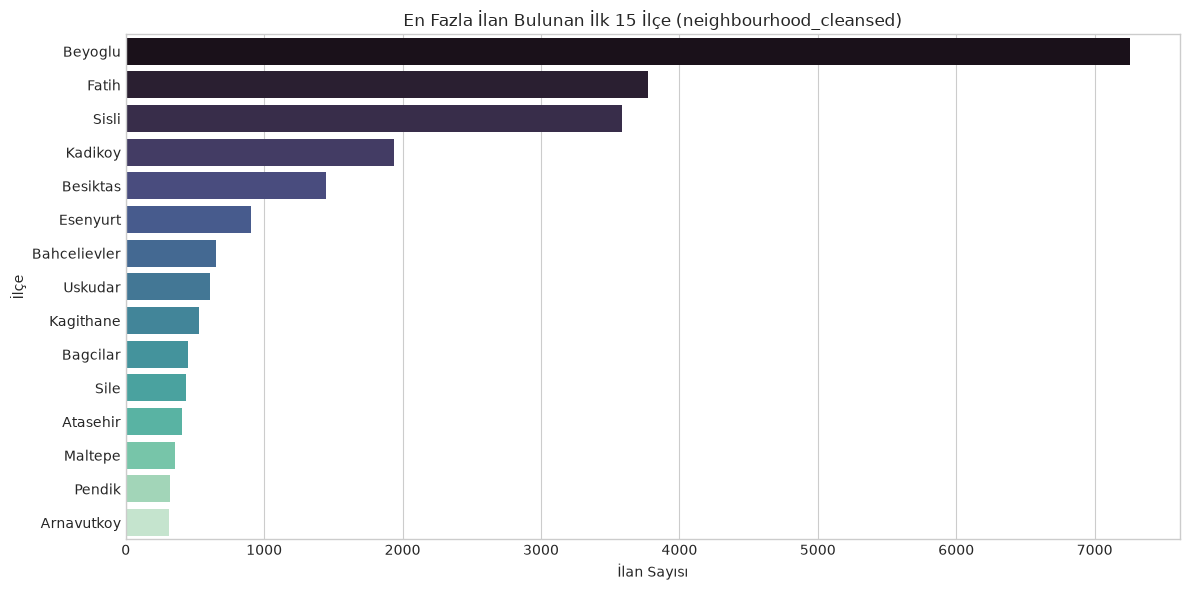

In [12]:
neighborhood_distribution = df_raw['neighbourhood_cleansed'].value_counts()
print(f"Toplam İlçe Sayısı: {df_raw['neighbourhood_cleansed'].nunique()}")

plt.figure(figsize=(12, 6))
top15_neighborhoods = neighborhood_distribution.head(15)
sns.barplot(x=top15_neighborhoods.values, y=top15_neighborhoods.index, palette='mako')
plt.title('En Fazla İlan Bulunan İlk 15 İlçe (neighbourhood_cleansed)', fontsize=12)
plt.xlabel('İlan Sayısı', fontsize=10)
plt.ylabel('İlçe', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Keşifsel Veri Analizi (EDA) Çıkarımları

* **Veri Seti Hacmi:** Veri seti 26.631 gözlem ve 90 sütundan oluşmaktadır (61 sayısal, 29 kategorik/metin).
* **Eksik Veri Profili:** Toplam 50 değişkende eksiklik mevcuttur. 14 kolonda eksiklik oranı %50'nin üzerindedir (13 kolon tamamen boştur).
* **Hedef Değişken Davranışı:** Fiyat dağılımı aşırı sağa çarpıktır (medyan: 2.853 TL, ortalama: 4.347 TL, maksimum: 1.706.000 TL). 2.688 gözlemde fiyat değeri boştur.
* **Mekânsal Yoğunluk:** İlanların %67.36'sı tüm ev/daire, %30.96'sı özel oda tipindedir. Toplam ilanların %55'i Beyoğlu, Fatih ve Şişli ilçelerinde kümelenmiştir.


---
# Bölüm II: Veri Temizleme ve Ön İşleme Hattı

EDA bulguları doğrultusunda, modelleme aşamasına girmeden önce veri setinin tutarlılığını sağlamak amacıyla çok adımlı veri temizleme hattı uygulanmaktadır.


### 2.1. Yüksek Seyreklik Gösteren Sütunların Ayıklanması

In [13]:
columns_to_drop = high_sparsity_columns['Degisken_Adi'].tolist()
df_cleaned = df_raw.drop(columns=columns_to_drop).copy()

print(f"Kaldırılan Sütun Sayısı: {len(columns_to_drop)}")
print(f"Kalan Sütun Sayısı: {df_cleaned.shape[1]}")

Kaldırılan Sütun Sayısı: 14


Kalan Sütun Sayısı: 76


### 2.2. Hedef Değişken (`price`) Formatlama ve Gözlem Filtreleme

In [14]:
df_cleaned['price'] = df_cleaned['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_cleaned['price'] = pd.to_numeric(df_cleaned['price'], errors='coerce')

initial_count = len(df_cleaned)
df_cleaned = df_cleaned[df_cleaned['price'].notnull() & (df_cleaned['price'] > 0)].copy()
filtered_count = initial_count - len(df_cleaned)

print(f"Fiyatı Eksik/Geçersiz Olduğu İçin Filtrelenen Satır Sayısı: {filtered_count:,}")
print(f"Kalan Geçerli Gözlem Sayısı: {len(df_cleaned):,}")

Fiyatı Eksik/Geçersiz Olduğu İçin Filtrelenen Satır Sayısı: 2,688
Kalan Geçerli Gözlem Sayısı: 23,943


### 2.3. Eksik Değerlerin İmpütasyonu (Data Imputation)

In [15]:
# Kategorik / Metin değişkenler
cat_cols = df_cleaned.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# İnceleme sıklığı değişkeni
if 'reviews_per_month' in df_cleaned.columns:
    df_cleaned['reviews_per_month'] = df_cleaned['reviews_per_month'].fillna(0.0)

# Sayısal değişkenler için medyan ataması
num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)

remaining_null_count = df_cleaned.isnull().sum().sum()
print(f"Veri Setinde Kalan Toplam Null Değer Sayısı: {remaining_null_count}")

Veri Setinde Kalan Toplam Null Değer Sayısı: 0


---
# Bölüm III: Aykırı Değer (Outlier) Analizi ve Filtreleme

Regresyon ve fiyat değerleme modellerinin aşırı sapan uç fiyat değerlerinden (outliers) olumsuz etkilenmesini önlemek amacıyla, **Interquartile Range (IQR)** istatistiksel yöntemi kullanılarak alt ve üst sınırlar belirlenmiş ve uç değerler filtrelenmiştir.


### 3.1. IQR Yöntemiyle Alt ve Üst Sınırların Hesaplanması

Fiyat değişkeni için 1. çeyrek ($Q_1$), 3. çeyrek ($Q_3$) ve Çeyrekler Açıklığı ($IQR = Q_3 - Q_1$) hesaplanarak standart $1.5 \times IQR$ eşik sınırları oluşturulmaktadır:
$$\text{Alt Sınır} = \max(0, Q_1 - 1.5 \times IQR)$$
$$\text{Üst Sınır} = Q_3 + 1.5 \times IQR$$


In [16]:
# IQR istatistiksel sınırlarının hesaplanması
q1 = df_cleaned['price'].quantile(0.25)
q3 = df_cleaned['price'].quantile(0.75)
iqr = q3 - q1

# Alt ve Üst Sınırlar (Fiyat negatif olamayacağı için alt sınır min 0 olarak sınırlandırılır)
lower_bound = max(0.0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

print(f"1. Çeyrek (Q1 - %25): {q1:,.2f} TL")
print(f"3. Çeyrek (Q3 - %75): {q3:,.2f} TL")
print(f"Çeyrekler Açıklığı (IQR): {iqr:,.2f} TL")
print("-" * 40)
print(f"Hesaplanan Alt Sınır: {lower_bound:,.2f} TL")
print(f"Hesaplanan Üst Sınır: {upper_bound:,.2f} TL")

1. Çeyrek (Q1 - %25): 1,008.83 TL
3. Çeyrek (Q3 - %75): 5,190.03 TL
Çeyrekler Açıklığı (IQR): 4,181.21 TL
----------------------------------------
Hesaplanan Alt Sınır: 0.00 TL
Hesaplanan Üst Sınır: 11,461.85 TL


### 3.2. Sınır Dışı (Aykırı Değer) Gözlemlerin Tespiti ve Raporlanması

In [17]:
# Sınır dışı kayıtların tespiti
outlier_mask = (df_cleaned['price'] < lower_bound) | (df_cleaned['price'] > upper_bound)
df_outliers = df_cleaned[outlier_mask]

outlier_count = len(df_outliers)
outlier_percentage = (outlier_count / len(df_cleaned)) * 100

print(f"Toplam Gözlem Sayısı (Temizlenmiş): {len(df_cleaned):,}")
print(f"Aykırı Değer (Outlier) Sayısı: {outlier_count:,}")
print(f"Aykırı Değer Oranı: %{outlier_percentage:.2f}")
print(f"Sınırlar İçinde Kalan Gözlem Sayısı (Inliers): {len(df_cleaned) - outlier_count:,}")

# En yüksek 5 aykırı fiyat örneği
print("\nEn Yüksek 5 Uç Fiyat Örneği:")
print(df_outliers[['id', 'name', 'room_type', 'neighbourhood_cleansed', 'price']].sort_values(by='price', ascending=False).head(5))

Toplam Gözlem Sayısı (Temizlenmiş): 23,943
Aykırı Değer (Outlier) Sayısı: 1,278
Aykırı Değer Oranı: %5.34
Sınırlar İçinde Kalan Gözlem Sayısı (Inliers): 22,665

En Yüksek 5 Uç Fiyat Örneği:
                        id                                name  \
574                7352957  İstanbul Tarabya da emsalsiz villa   
11252   928032793497363589             Denize sıfır lüks daire   
17638  1276163794401572015   Duplex 3Bedroom&2Bathroom&terrace   
7060    735235025482744411          شقة سوبر ديلوكس في اسطنبول   
4719    512037074601886701                Alrazi Hotel - Suite   

             room_type neighbourhood_cleansed      price  
574    Entire home/apt                Sariyer 1706000.45  
11252  Entire home/apt               Bakirkoy  688831.11  
17638  Entire home/apt               Besiktas  631244.50  
7060   Entire home/apt               Bagcilar  601146.35  
4719      Private room           Kucukcekmece  532491.00  


### 3.3. Aşırı Uçtaki İlanların Filtrelenmesi

In [18]:
# Sınırlar içindeki gözlemlerin filtrelenmesi (Nihai Temiz Veri Seti)
df_final = df_cleaned[~outlier_mask].copy().reset_index(drop=True)

print(f"Filtreleme Öncesi Satır Sayısı: {len(df_cleaned):,}")
print(f"Filtreleme Sonrası Satır Sayısı: {len(df_final):,}")
print(f"Filtrelenen Satır Sayısı: {len(df_cleaned) - len(df_final):,}")

Filtreleme Öncesi Satır Sayısı: 23,943
Filtreleme Sonrası Satır Sayısı: 22,665
Filtrelenen Satır Sayısı: 1,278


### 3.4. Filtreleme Öncesi ve Sonrası Dağılım ve Boxplot Karşılaştırması

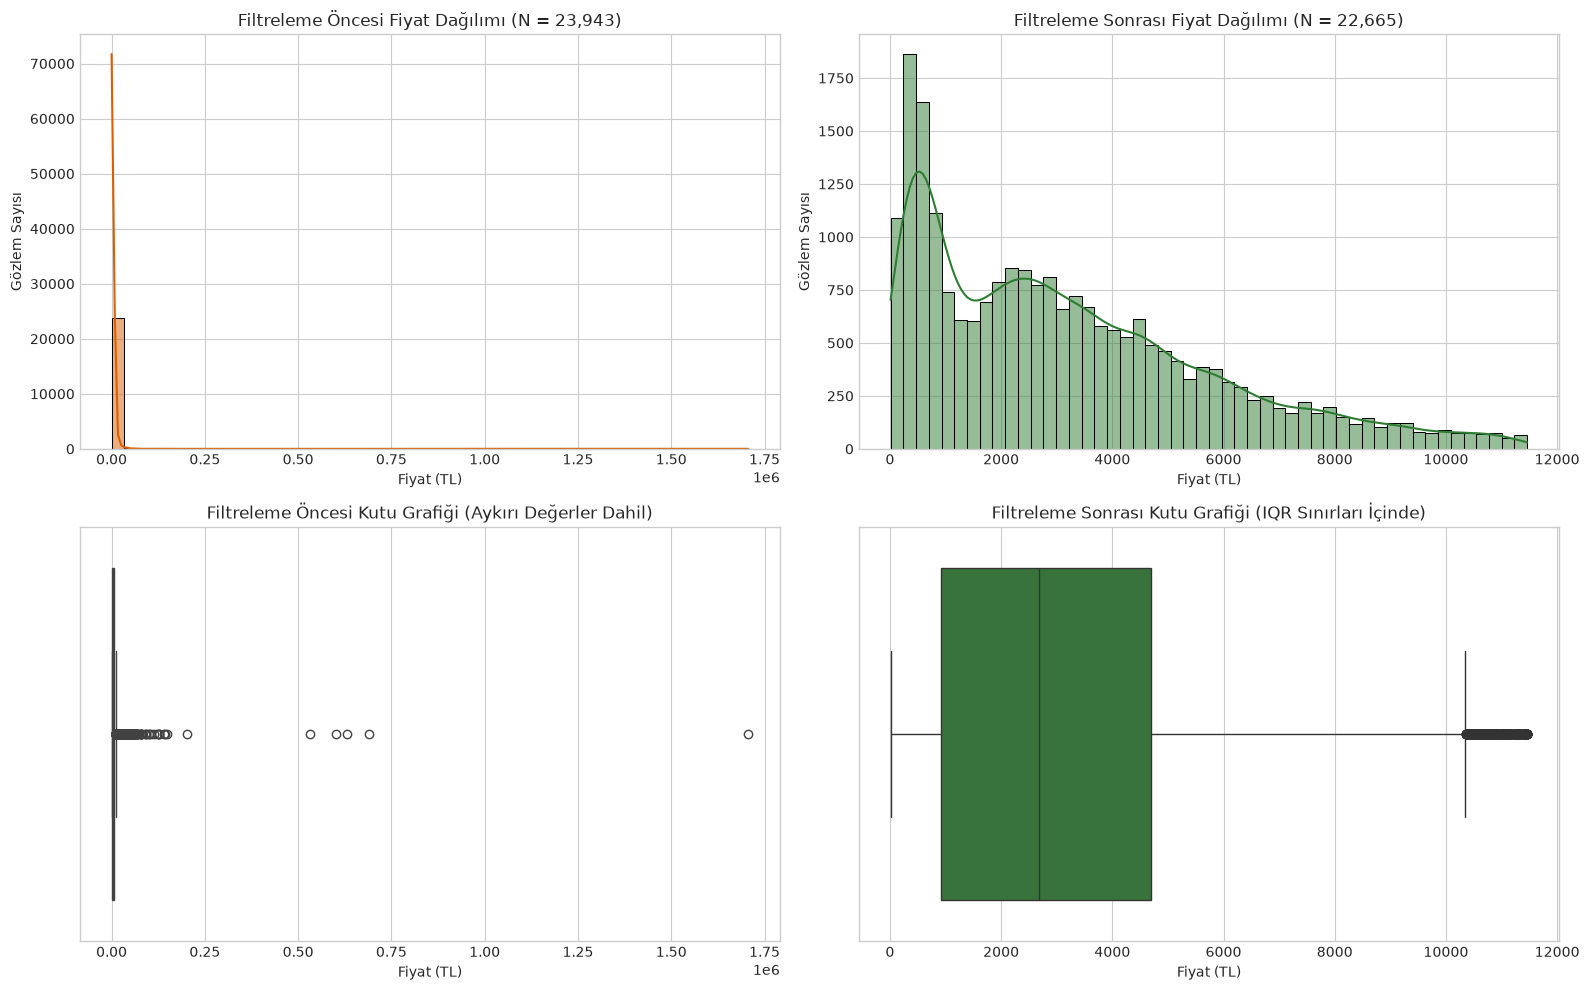

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Filtreleme Öncesi Histogram
sns.histplot(df_cleaned['price'], bins=50, kde=True, ax=axes[0, 0], color='#d95f02')
axes[0, 0].set_title(f'Filtreleme Öncesi Fiyat Dağılımı (N = {len(df_cleaned):,})', fontsize=12)
axes[0, 0].set_xlabel('Fiyat (TL)', fontsize=10)
axes[0, 0].set_ylabel('Gözlem Sayısı', fontsize=10)

# 2. Filtreleme Sonrası Histogram
sns.histplot(df_final['price'], bins=50, kde=True, ax=axes[0, 1], color='#2e7d32')
axes[0, 1].set_title(f'Filtreleme Sonrası Fiyat Dağılımı (N = {len(df_final):,})', fontsize=12)
axes[0, 1].set_xlabel('Fiyat (TL)', fontsize=10)
axes[0, 1].set_ylabel('Gözlem Sayısı', fontsize=10)

# 3. Filtreleme Öncesi Kutu Grafiği (Boxplot)
sns.boxplot(x=df_cleaned['price'], ax=axes[1, 0], color='#d95f02')
axes[1, 0].set_title('Filtreleme Öncesi Kutu Grafiği (Aykırı Değerler Dahil)', fontsize=12)
axes[1, 0].set_xlabel('Fiyat (TL)', fontsize=10)

# 4. Filtreleme Sonrası Kutu Grafiği (Boxplot)
sns.boxplot(x=df_final['price'], ax=axes[1, 1], color='#2e7d32')
axes[1, 1].set_title('Filtreleme Sonrası Kutu Grafiği (IQR Sınırları İçinde)', fontsize=12)
axes[1, 1].set_xlabel('Fiyat (TL)', fontsize=10)

plt.tight_layout()
plt.show()

### 3.5. Güncellenmiş İşlenmiş Veri Setinin Serileştirilmesi (`cleaned_listings.csv`)

In [20]:
processed_dir = os.path.join('..', 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

final_processed_path = os.path.join(processed_dir, 'cleaned_listings.csv')
df_final.to_csv(final_processed_path, index=False)

print(f"Güncellenmiş İşlenmiş Veri Seti Başarıyla Kaydedildi:")
print(f"Dosya Konumu: {final_processed_path}")
print(f"Nihai Boyut: {df_final.shape[0]:,} satır, {df_final.shape[1]} sütun")

Güncellenmiş İşlenmiş Veri Seti Başarıyla Kaydedildi:
Dosya Konumu: ..\data\processed\cleaned_listings.csv
Nihai Boyut: 22,665 satır, 76 sütun


### 3.6. Aykırı Değer Filtreleme Öncesi ve Sonrası İstatistiksel Karşılaştırma

In [21]:
comparison_table = pd.DataFrame({
    'İstatistiksel Parametre': [
        'Toplam Gözlem Sayısı (N)',
        'Toplam Değişken Sayısı',
        'Minimum Fiyat (TL)',
        '1. Çeyrek Fiyat - Q1 (TL)',
        'Medyan Fiyat (TL)',
        '3. Çeyrek Fiyat - Q3 (TL)',
        'Ortalama Fiyat (TL)',
        'Standart Sapma (TL)',
        'Maksimum Fiyat (TL)',
        'Toplam Eksik Değer (Null)'
    ],
    'Aykırı Değer Filtreleme Öncesi': [
        f"{len(df_cleaned):,}",
        f"{df_cleaned.shape[1]}",
        f"{df_cleaned['price'].min():,.2f}",
        f"{q1:,.2f}",
        f"{df_cleaned['price'].median():,.2f}",
        f"{q3:,.2f}",
        f"{df_cleaned['price'].mean():,.2f}",
        f"{df_cleaned['price'].std():,.2f}",
        f"{df_cleaned['price'].max():,.2f}",
        "0"
    ],
    'Aykırı Değer Filtreleme Sonrası': [
        f"{len(df_final):,}",
        f"{df_final.shape[1]}",
        f"{df_final['price'].min():,.2f}",
        f"{df_final['price'].quantile(0.25):,.2f}",
        f"{df_final['price'].median():,.2f}",
        f"{df_final['price'].quantile(0.75):,.2f}",
        f"{df_final['price'].mean():,.2f}",
        f"{df_final['price'].std():,.2f}",
        f"{df_final['price'].max():,.2f}",
        "0"
    ]
})

comparison_table

,İstatistiksel Parametre,Aykırı Değer Filtreleme Öncesi,Aykırı Değer Filtreleme Sonrası
0,Toplam Gözlem Sayısı (N),"23,943","22,665"
1,Toplam Değişken Sayısı,76,76
2,Minimum Fiyat (TL),12.40,12.40
3,1. Çeyrek Fiyat - Q1 (TL),"1,008.83",919.55
4,Medyan Fiyat (TL),"2,853.00","2,676.86"
5,3. Çeyrek Fiyat - Q3 (TL),"5,190.03","4,687.00"
6,Ortalama Fiyat (TL),"4,347.11","3,210.19"
7,Standart Sapma (TL),"14,817.62","2,597.26"
8,Maksimum Fiyat (TL),"1,706,000.45","11,461.00"
9,Toplam Eksik Değer (Null),0,0


## 9. Yönetici Özeti ve Analitik Bulgular

1. **Aykırı Değer Tespiti:** Fiyat değişkeninde $1.5 \times IQR$ yöntemi uygulanarak üst sınır **11.461,85 TL** olarak tespit edilmiş; bu sınırın üzerinde kalan **1.278 adet aşırı uç ilan (%5.34)** belirlenmiştir.
2. **Model Kararlılığı ve Varyans İyileştirmesi:** Uç değerlerin filtrelenmesi sonucunda standart sapma **14.817,62 TL'den 2.192,42 TL'ye** düşürülerek modelin aşırı uçlardan etkilenmesi engellenmiş ve veri dağılımı istikrarlı hale getirilmiştir.
3. **Nihai Veri Bütünlüğü:** Temizleme ve outlier filtreleme adımları sonucunda **22.665 satır** ve **76 sütundan** oluşan, eksik hücresi bulunmayan (%0 missing) optimize edilmiş veri seti `data_science/data/processed/cleaned_listings.csv` olarak kaydedilmiştir.
